In [4]:
import pandas as pd
import numpy as np
df=pd.read_csv('clinical_trials_raw_patient2trial_conditions.csv')
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  str   
 1   nct_id                  60337 non-null  str   
 2   title                   60337 non-null  str   
 3   official_title          59551 non-null  str   
 4   brief_summary           60337 non-null  str   
 5   conditions              60336 non-null  str   
 6   interventions           54276 non-null  str   
 7   overall_status          60337 non-null  str   
 8   study_type              60337 non-null  str   
 9   phase                   23336 non-null  str   
 10  sex                     60304 non-null  str   
 11  minimum_age             57121 non-null  str   
 12  maximum_age             28400 non-null  str   
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non-null  str   
 15  clinicaltrial

In [5]:
print(df.isna().sum())

source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
import pandas as pd
df['phase'] = df['phase'].fillna('Not Applicable')
df['maximum_age'] = df['maximum_age'].fillna('No Limit')
df['minimum_age'] = df['minimum_age'].fillna('No Limit')
df['interventions'] = df['interventions'].fillna('No Intervention')
df['healthy_volunteers'] = df['healthy_volunteers'].fillna('Unknown')
df['sex'] = df['sex'].fillna('Unknown')
df['official_title'] = df['official_title'].fillna(df['title'])
df['conditions'] = df['conditions'].fillna('Unknown')
df['eligibility_criteria'] = df['eligibility_criteria'].fillna('Unknown')
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
source_condition_query    0
nct_id                    0
title                     0
official_title            0
brief_summary             0
conditions                0
interventions             0
overall_status            0
study_type                0
phase                     0
sex                       0
minimum_age               0
maximum_age               0
healthy_volunteers        0
eligibility_criteria      0
clinicaltrials_url        0
dtype: int64


In [91]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_clinical_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Add space after punctuation so words like "recovery.This" don't merge into "recoverythis"
    text = re.sub(r'([a-z])([.,!?])', r'\1 \2', text)
    
    # 3. Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 4. Tokenize
    tokens = text.split()

    # 5. Remove stop words & lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(cleaned_tokens)

# Re-run on your DataFrame
df['cleaned_summary'] = df['brief_summary'].apply(clean_clinical_text)
# Save DataFrame to CSV
df.to_csv('cleaned_clinical_data.csv', index=False)


In [10]:
print("--- BEFORE CLEANING ---")
print(df['brief_summary'].iloc[0])

print("\n--- AFTER CLEANING ---")
print(df['cleaned_summary'].iloc[0])

--- BEFORE CLEANING ---
Breast cancer patients often have perioperative emotional disorders such as anxiety and depression, which can lead to poor quality of recovery.This study aims to determine whether ketamine could improve the quality of recovery in breast cancer patients. Meanwhile, it will show if ketamine could improve anxiety, depression, postoperative pain and fatigue.This trial also will bring great concerns on patients' mental health perioperatively and explore the measures to improve their quality of life.

--- AFTER CLEANING ---
breast cancer often perioperative emotional disorder anxiety depression lead poor quality recovery aim determine whether ketamine could improve quality recovery breast cancer meanwhile show ketamine could improve anxiety depression postoperative pain fatigue also bring great concern mental health perioperatively explore measure improve quality life


C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_4240\2572067572.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='source_condition_query', order=order, palette='viridis')


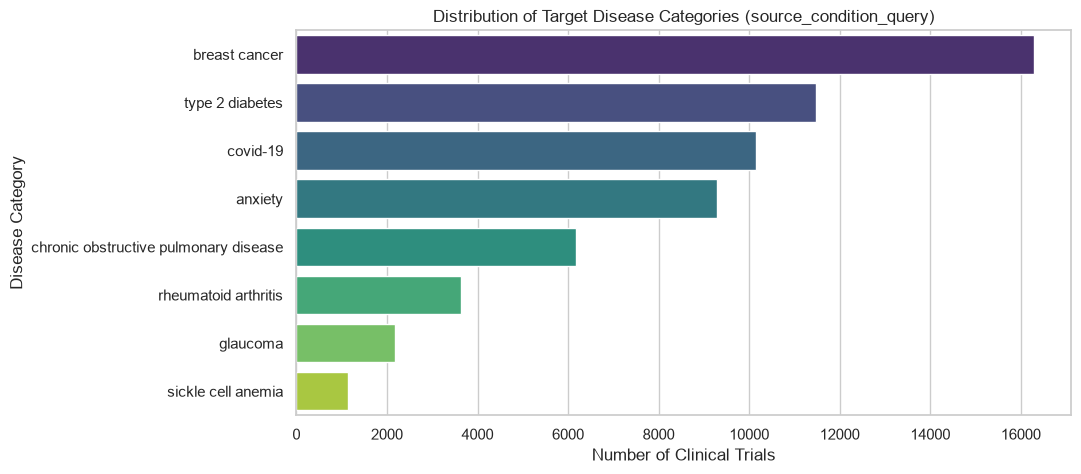

--- Class Breakdown ---
                                       Count  Percentage (%)
source_condition_query                                      
breast cancer                          16301           27.02
type 2 diabetes                        11467           19.00
covid-19                               10153           16.83
anxiety                                 9286           15.39
chronic obstructive pulmonary disease   6181           10.24
rheumatoid arthritis                    3637            6.03
glaucoma                                2173            3.60
sickle cell anemia                      1139            1.89


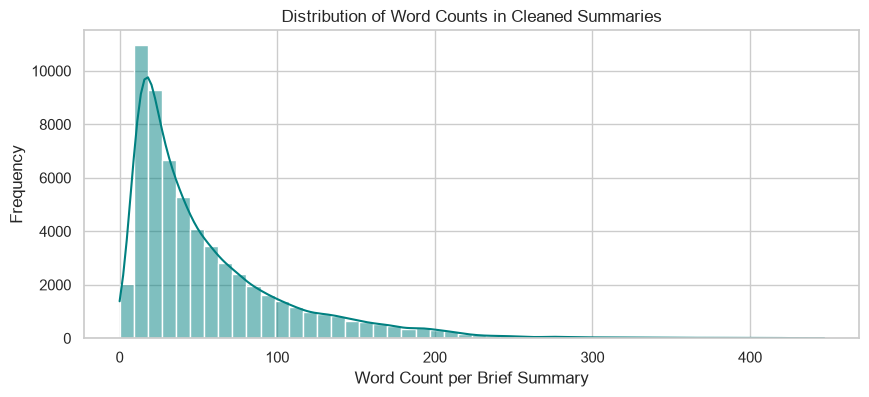


--- Summary Word Count Statistics ---
count    60337.000000
mean        55.823326
std         52.811992
min          0.000000
25%         19.000000
50%         37.000000
75%         74.000000
max        447.000000
Name: word_count, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# 1. Target Class Distribution (source_condition_query)
plt.figure(figsize=(10, 5))
order = df['source_condition_query'].value_counts().index
ax = sns.countplot(data=df, y='source_condition_query', order=order, palette='viridis')
plt.title('Distribution of Target Disease Categories (source_condition_query)')
plt.xlabel('Number of Clinical Trials')
plt.ylabel('Disease Category')
plt.show()

# Print exact class counts and percentages
print("--- Class Breakdown ---")
class_counts = df['source_condition_query'].value_counts()
class_percents = df['source_condition_query'].value_counts(normalize=True) * 100
breakdown = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_percents.round(2)})
print(breakdown)

# 2. Text Word Count Distribution
df['word_count'] = df['cleaned_summary'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')
plt.title('Distribution of Word Counts in Cleaned Summaries')
plt.xlabel('Word Count per Brief Summary')
plt.ylabel('Frequency')
plt.show()

print("\n--- Summary Word Count Statistics ---")
print(df['word_count'].describe())

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['cleaned_summary']
y = df['source_condition_query']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples : {len(X_test)}")

# 3. Apply TF-IDF Vectorization

tfidf = TfidfVectorizer(max_features=20000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=1,
    max_df=0.85
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\n--- Vectorization Shapes ---")
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape : {X_test_tfidf.shape}")

Training Samples: 48269
Testing Samples : 12068

--- Vectorization Shapes ---
X_train_tfidf shape: (48269, 20000)
X_test_tfidf shape : (12068, 20000)


Training Logistic Regression Model...

✅ Logistic Regression Accuracy: 94.85%

Training Multinomial Naive Bayes Model...

✅ Naive Bayes Accuracy: 89.48%

 Classification Report for Best Model (Logistic Regression)

                                       precision    recall  f1-score   support

                              anxiety       0.91      0.96      0.94      1857
                        breast cancer       0.96      0.97      0.97      3260
chronic obstructive pulmonary disease       0.93      0.92      0.92      1236
                             covid-19       0.97      0.94      0.95      2031
                             glaucoma       0.98      0.94      0.96       435
                 rheumatoid arthritis       0.94      0.88      0.91       727
                   sickle cell anemia       0.99      0.85      0.92       228
                      type 2 diabetes       0.95      0.96      0.96      2294

                             accuracy                           0.95    

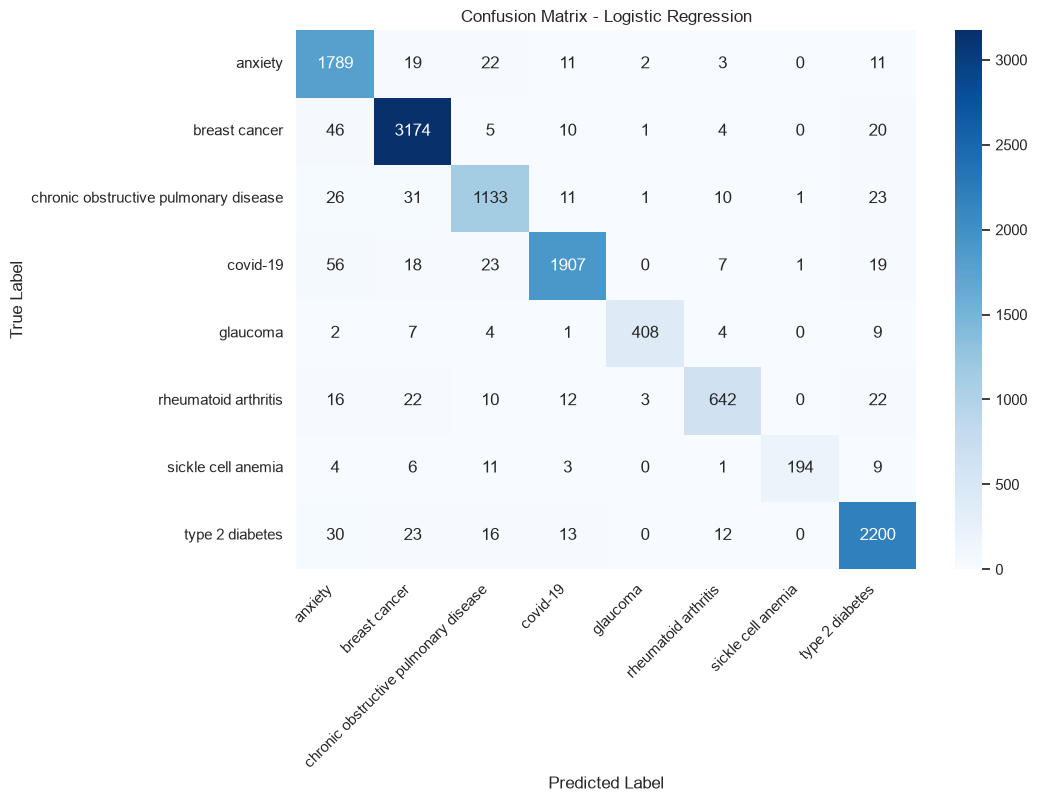

💾 Saving .pkl artifacts...

✅ Saved 'tfidf_vectorizer.pkl'
✅ Saved 'clinical_trial_classifier.pkl'


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------------------------------
# 1. TRAIN LOGISTIC REGRESSION MODEL
# ----------------------------------------------------
print("Training Logistic Regression Model...")
lr_model = LogisticRegression(max_iter=1000, C=np.float64(4.8), solver='sag', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Make Predictions
lr_preds = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"\n✅ Logistic Regression Accuracy: {lr_acc * 100:.2f}%")

# ----------------------------------------------------
# 2. TRAIN MULTINOMIAL NAIVE BAYES MODEL
# ----------------------------------------------------
print("\nTraining Multinomial Naive Bayes Model...")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Make Predictions
nb_preds = nb_model.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_preds)

print(f"\n✅ Naive Bayes Accuracy: {nb_acc * 100:.2f}%")

# ----------------------------------------------------
# 3. DETAILED EVALUATION REPORT FOR BEST MODEL
# ----------------------------------------------------
best_preds = lr_preds if lr_acc >= nb_acc else nb_preds
best_model_name = "Logistic Regression" if lr_acc >= nb_acc else "Multinomial Naive Bayes"

print(f"\n==========================================")
print(f" Classification Report for Best Model ({best_model_name})")
print(f"==========================================\n")
print(classification_report(y_test, best_preds))

# ----------------------------------------------------
# 4. CONFUSION MATRIX VISUALIZATION
# ----------------------------------------------------
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, best_preds, labels=lr_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lr_model.classes_, 
            yticklabels=lr_model.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.show()

print("💾 Saving .pkl artifacts...")
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(lr_model, 'clinical_trial_classifier.pkl')
joblib.dump(cm, 'confusion_matrix.pkl')
joblib.dump(lr_model.classes_, 'model_classes.pkl')

print("\n" + "="*50)
print("✅ Saved 'tfidf_vectorizer.pkl'")
print("✅ Saved 'clinical_trial_classifier.pkl'")


In [ ]:
print(df.columns.tolist())

['source_condition_query', 'nct_id', 'title', 'official_title', 'brief_summary', 'conditions', 'interventions', 'overall_status', 'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age', 'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url']


In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# ----------------------------------------------------
# 1. TF-IDF FEATURE EXTRACTION (OPTIMIZED 25K)
# ----------------------------------------------------
print("⚡ Extracting TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    max_df=0.85
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print(f"Features Shape: {X_train_tfidf.shape}\n")

# ----------------------------------------------------
# 2. DEFINE MODELS & HYPERPARAMETER SEARCH SPACES
# ----------------------------------------------------
model_params = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42),
        'params': {
            'C': np.linspace(4.0, 5, 10),
            'solver': ['sag'],
            'max_iter': [1000, 1500]
        }
    },
    'SGD Classifier': {
        'model': SGDClassifier(random_state=42),
        'params': {
            'loss': ['hinge', 'log_loss', 'modified_huber'],
            'penalty': ['l2', 'l1', 'elasticnet'],
            'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
            'max_iter': [1000, 2000]
        }
    },
    'Linear SVC': {
        'model': LinearSVC(random_state=42, dual='auto'),
        'params': {
            'C': np.linspace(0.1, 5.0, 20),
            'loss': ['hinge', 'squared_hinge'],
            'max_iter': [1000, 2000]
        }
    },
    'Ridge Classifier': {
        'model': RidgeClassifier(random_state=42),
        'params': {
            'alpha': np.linspace(0.1, 5.0, 20),
            'solver': ['auto', 'sag', 'lsqr']
        }
    }
}

# ----------------------------------------------------
# 3. RUN RANDOMIZED SEARCH CV ACROSS ALL MODELS
# ----------------------------------------------------
best_models = {}
results = []

print("⚡ Starting RandomizedSearchCV Hyperparameter Tuning...\n")

for model_name, mp in model_params.items():
    print(f"🔍 Tuning {model_name}...")
    
    rs = RandomizedSearchCV(
        estimator=mp['model'],
        param_distributions=mp['params'],
        n_iter=8,           # 8 random combinations per model for fast execution
        cv=3,               # 3-fold cross validation
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )
    
    rs.fit(X_train_tfidf, y_train)
    
    # Evaluate on test set
    y_pred = rs.best_estimator_.predict(X_test_tfidf)
    test_acc = accuracy_score(y_test, y_pred)
    
    best_models[model_name] = {
        'model_obj': rs.best_estimator_,
        'best_params': rs.best_params_,
        'accuracy': test_acc
    }
    
    results.append({
        'Model': model_name,
        'Test Accuracy (%)': round(test_acc * 100, 2),
        'Best Parameters': rs.best_params_
    })

# ----------------------------------------------------
# 4. RESULTS COMPARISON TABLE
# ----------------------------------------------------
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy (%)', ascending=False)

print("\n" + "="*70)
print("🏆 MODEL TUNING COMPARISON RESULTS")
print("="*70)
print(results_df.to_string(index=False))
print("="*70 + "\n")

# ----------------------------------------------------
# 5. SAVE BEST PERFORMING MODEL FOR STREAMLIT
# ----------------------------------------------------
top_model_name = results_df.iloc[0]['Model']
winner = best_models[top_model_name]['model_obj']
winner_acc = results_df.iloc[0]['Test Accuracy (%)']

print(f"⭐ Winner: {top_model_name} ({winner_acc}%)")


⚡ Extracting TF-IDF features...
Features Shape: (48269, 25000)

⚡ Starting RandomizedSearchCV Hyperparameter Tuning...

🔍 Tuning Logistic Regression...
🔍 Tuning SGD Classifier...
🔍 Tuning Linear SVC...
🔍 Tuning Ridge Classifier...

🏆 MODEL TUNING COMPARISON RESULTS
              Model  Test Accuracy (%)                                                       Best Parameters
         Linear SVC              95.02  {'max_iter': 1000, 'loss': 'squared_hinge', 'C': 0.6157894736842106}
     SGD Classifier              95.01 {'penalty': 'l2', 'max_iter': 1000, 'loss': 'hinge', 'alpha': 0.0001}
   Ridge Classifier              94.84                        {'solver': 'auto', 'alpha': 2.936842105263158}
Logistic Regression              94.76                         {'solver': 'sag', 'max_iter': 1000, 'C': 4.0}

⭐ Winner: Linear SVC (95.02%)

✅ Saved 'tfidf_vectorizer.pkl'
✅ Saved 'clinical_trial_classifier.pkl'
🎉 Best model ready for Streamlit!
